In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import numpy as np # linear algebra
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from matplotlib import pyplot as plt

In [2]:
# --- [CELL 1]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# === BEFORE (original) ===
# import pathlib
# data_dir = 'data/web_scraped_small'
# data_dir = pathlib.Path(data_dir).with_suffix('')

# === AFTER (edited) ===
import pathlib
import PIL

data_dir = pathlib.Path('data/web_scraped_small')

# Remove files that are not valid images so tf loader won't crash at decode time
valid_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}
for class_dir in data_dir.iterdir():
    if class_dir.is_dir():
        for p in class_dir.iterdir():
            if not p.is_file():
                continue
            if p.suffix.lower() not in valid_exts:
                try:
                    p.unlink()
                except Exception:
                    pass
                continue
            try:
                with PIL.Image.open(p) as img:
                    img.verify()
            except Exception:
                try:
                    p.unlink()
                except Exception:
                    pass

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

39

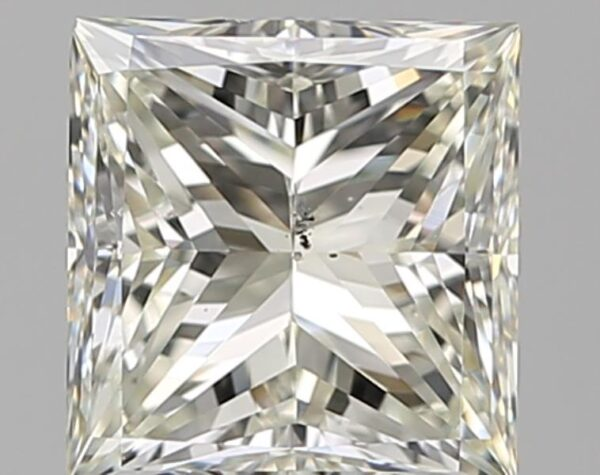

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
import PIL
princess = list(data_dir.glob('princess/*'))
PIL.Image.open(str(princess[1]))

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
image_height, image_width = PIL.Image.open(str(princess[1])).size
batch_size,epochs = 64,10

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    image_size=(image_height, image_width),
    seed = 1,
    shuffle=True,
    batch_size=batch_size
)

Found 39 files belonging to 8 classes.
Using 32 files for training.


In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    image_size=(image_height, image_width),
    seed = 1,
    shuffle=True,
    batch_size=batch_size
)

Found 39 files belonging to 8 classes.
Using 7 files for validation.


In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
normalization_layer = layers.Rescaling(1./255)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
from tensorflow import keras
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(image_height,
                                  image_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
num_of_classes = len(train_ds.class_names)
num_of_classes

8

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
model = Sequential([
  data_augmentation,
  normalization_layer,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_of_classes, name="outputs")
])

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
history = model.fit(train_ds,validation_data=val_ds, epochs=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.0938 - loss: 2.1057 - val_accuracy: 0.0000e+00 - val_loss: 33.7537
